In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("/Users/pushkal/Downloads/Social Media Engagement Dataset.csv") 
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (12000, 28)
        post_id            timestamp day_of_week   platform        user_id  \
0  kcqbs6hxybia  2024-12-09 11:26:15      Monday  Instagram  user_52nwb0a6   
1  vkmervg4ioos  2024-07-28 19:59:26      Sunday    Twitter  user_ucryct98   
2  memhx4o1x6yu  2024-11-23 14:00:12    Saturday     Reddit  user_7rrev126   
3  bhyo6piijqt9  2024-09-16 04:35:25      Monday    YouTube  user_4mxuq0ax   
4  c9dkiomowakt  2024-09-05 21:03:01    Thursday    Twitter  user_l1vpox2k   

               location language  \
0  Melbourne, Australia       pt   
1          Tokyo, Japan       ru   
2        Beijing, China       ru   
3        Lagos, Nigeria       en   
4       Berlin, Germany       hi   

                                        text_content  \
0  Just tried the Chromebook from Google. Best pu...   
1  Just saw an ad for Microsoft Surface Laptop du...   
2  What's your opinion about Nike's Epic React?  ...   
3  Bummed out with my new Diet Pepsi from Pepsi! ...   
4  Just

In [8]:
df = df.dropna()
# convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8059 entries, 1 to 11999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   post_id                  8059 non-null   object        
 1   timestamp                8059 non-null   datetime64[ns]
 2   day_of_week              8059 non-null   object        
 3   platform                 8059 non-null   object        
 4   user_id                  8059 non-null   object        
 5   location                 8059 non-null   object        
 6   language                 8059 non-null   object        
 7   text_content             8059 non-null   object        
 8   hashtags                 8059 non-null   object        
 9   mentions                 8059 non-null   object        
 10  keywords                 8059 non-null   object        
 11  topic_category           8059 non-null   object        
 12  sentiment_score          8059 non-null

In [9]:
df["engagement"] = (
    df["likes_count"] +
    df["shares_count"] +
    df["comments_count"]
)

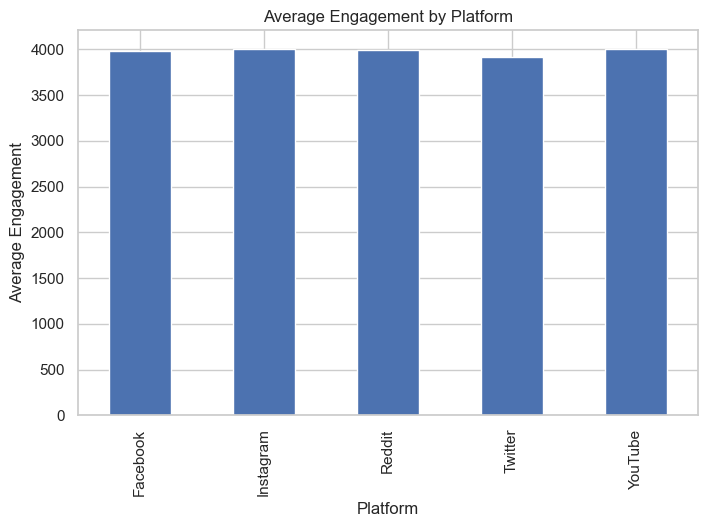

In [10]:
platform_engagement = df.groupby("platform")["engagement"].mean()
plt.figure(figsize=(8,5))
platform_engagement.plot(kind="bar")
plt.title("Average Engagement by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Engagement")
plt.show()

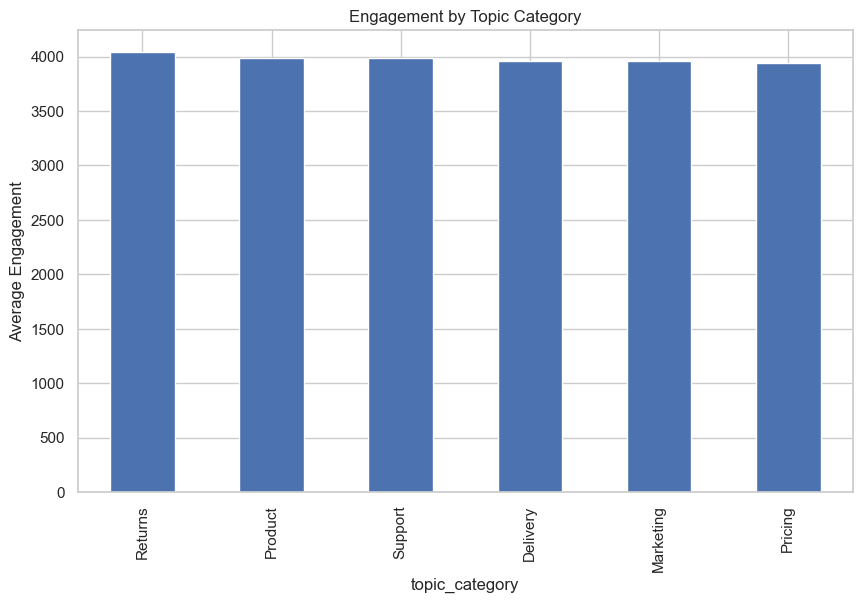

In [11]:
topic_engagement = df.groupby("topic_category")["engagement"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
topic_engagement.plot(kind="bar")
plt.title("Engagement by Topic Category")
plt.ylabel("Average Engagement")
plt.show()

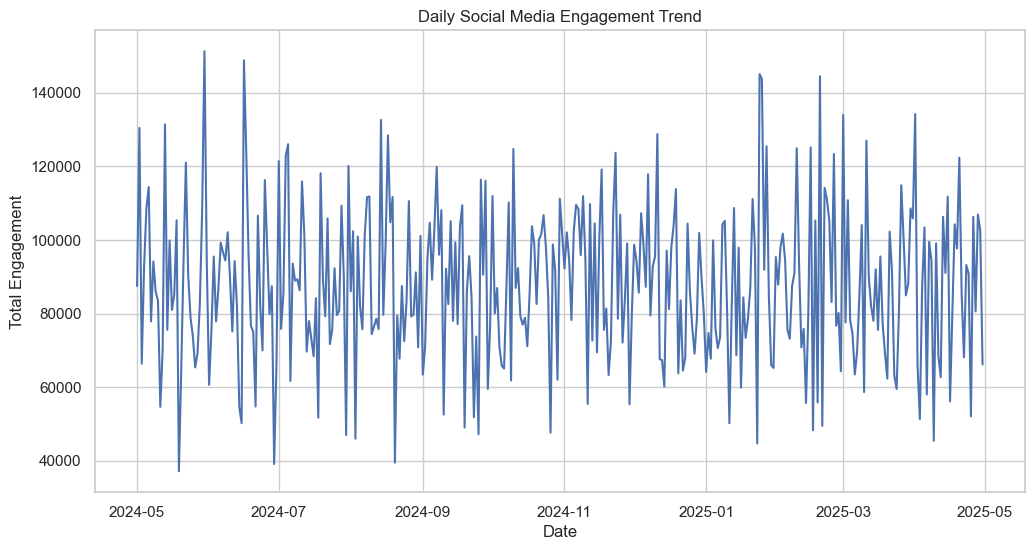

In [12]:
df["date"] = df["timestamp"].dt.date
daily_engagement = df.groupby("date")["engagement"].sum()
plt.figure(figsize=(12,6))
daily_engagement.plot()
plt.title("Daily Social Media Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Total Engagement")
plt.show()

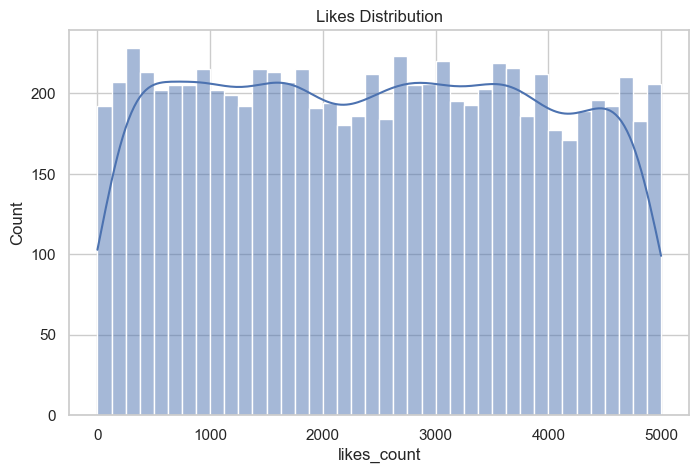

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["likes_count"], bins=40, kde=True)
plt.title("Likes Distribution")
plt.show()

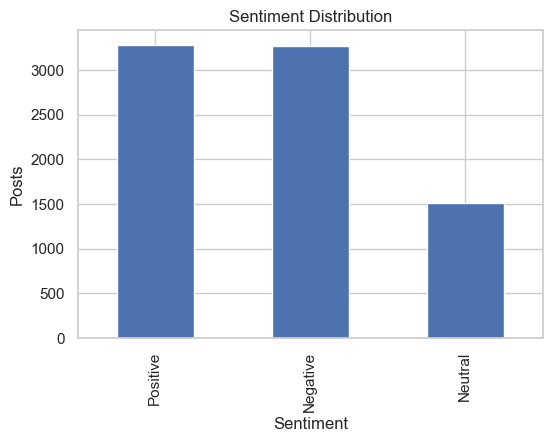

In [14]:
sentiment_counts = df["sentiment_label"].value_counts()
plt.figure(figsize=(6,4))
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Posts")
plt.show()

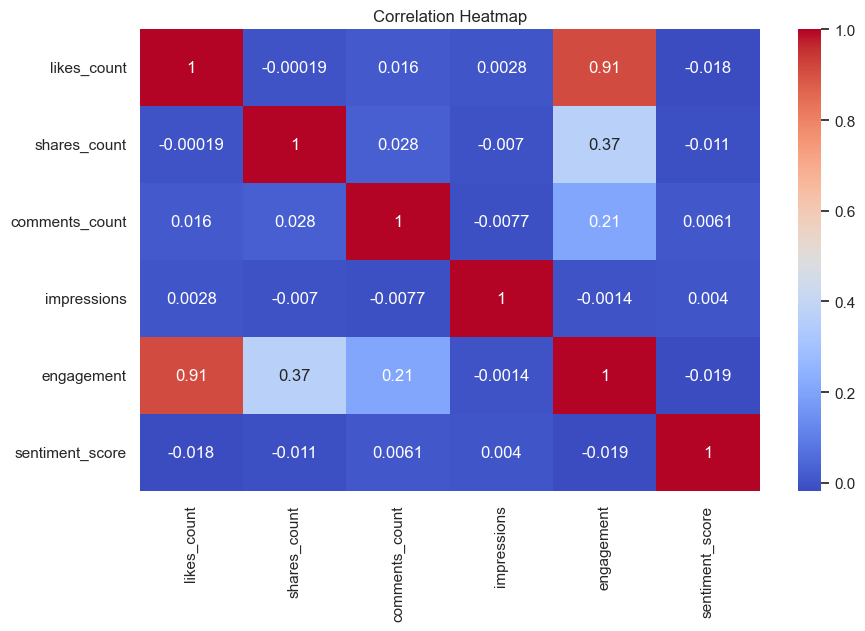

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[[
        "likes_count",
        "shares_count",
        "comments_count",
        "impressions",
        "engagement",
        "sentiment_score"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [16]:
top_posts = df.sort_values(by="engagement", ascending=False).head(10)
print(top_posts[
    [
        "platform",
        "topic_category",
        "likes_count",
        "shares_count",
        "comments_count",
        "engagement"
    ]
])

        platform topic_category  likes_count  shares_count  comments_count  \
459      YouTube      Marketing         4963          1987             950   
11947  Instagram        Returns         4983          1919             991   
8925      Reddit      Marketing         4913          1921             983   
1770    Facebook        Product         4902          1880             982   
6899     YouTube      Marketing         4923          1971             861   
11154  Instagram        Support         4989          1840             909   
4093     YouTube        Pricing         4979          1932             812   
3881   Instagram        Product         4931          1903             878   
6398     Twitter       Delivery         4914          1843             928   
141     Facebook        Returns         4811          1952             920   

       engagement  
459          7900  
11947        7893  
8925         7817  
1770         7764  
6899         7755  
11154        7738  
4